In [1]:
import numpy as np
import pandas as pd 
import seaborn as sns 
import warnings
import matplotlib.pyplot as mlp

In [2]:
df = pd.read_csv('sale.csv', encoding='latin1')

In [3]:
df.info()
df.describe()
df.head(5)
df.shape
df.dtypes
df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

np.int64(0)

In [4]:
df['Country'].unique()
df['Region'].unique()
df['Segment'].unique()
df[['Sales','Quantity','Discount','Profit']].describe()

,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.858001,3.789574,0.156203,28.656896
std,623.245101,2.225110,0.206452,234.260108
min,0.444000,1.000000,0.000000,-6599.978000
25%,17.280000,2.000000,0.000000,1.728750
50%,54.490000,3.000000,0.200000,8.666500
75%,209.940000,5.000000,0.200000,29.364000
max,22638.480000,14.000000,0.800000,8399.976000


In [5]:
df['Order Date']= pd.to_datetime(df['Order Date'])
df['Ship Date']= pd.to_datetime(df['Ship Date'])
df.head(5)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [6]:
df['Order Date'].max()
df['Order Date'].min()

Timestamp('2014-01-03 00:00:00')

In [7]:
df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month
df['Shipping Days'] = (df['Ship Date'] - df['Order Date']).dt.days


In [8]:
df[['Sales','Profit']].sum()

Sales     2.297201e+06
Profit    2.863970e+05
dtype: float64

In [9]:
category_profits =df.groupby('Category')[['Sales','Profit']].sum()
sub_c_loss=df.groupby('Sub-Category')['Profit'].sum().sort_values()


<Axes: xlabel='Category'>

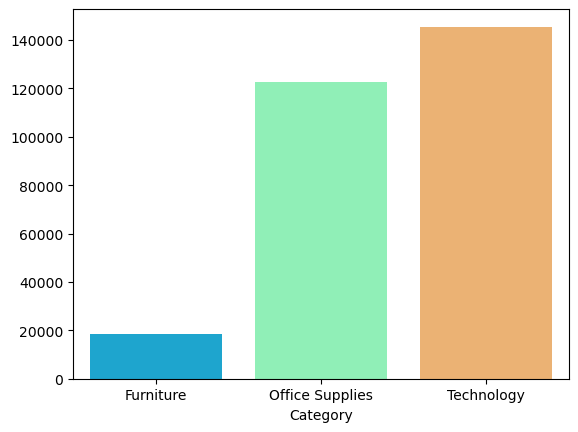

In [10]:
category_profit = df.groupby('Category')['Profit'].sum()
sns.barplot(x=category_profit.index, y=category_profit.values,
            hue=category_profit.index,
            palette='rainbow')


<Axes: ylabel='Sub-Category'>

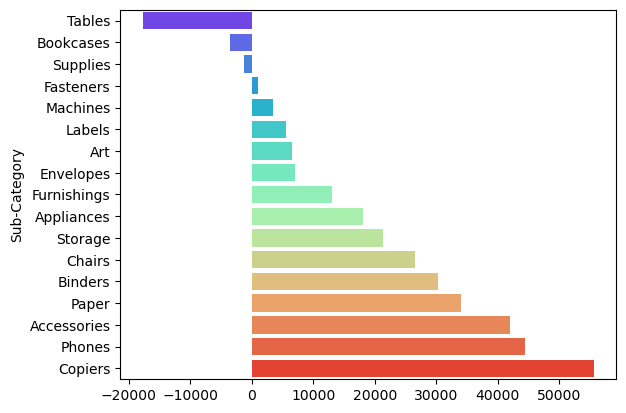

In [11]:

sns.barplot(y=sub_c_loss.index, x=sub_c_loss.values,
            hue=sub_c_loss.index,
            palette='rainbow')


<Axes: ylabel='Region'>

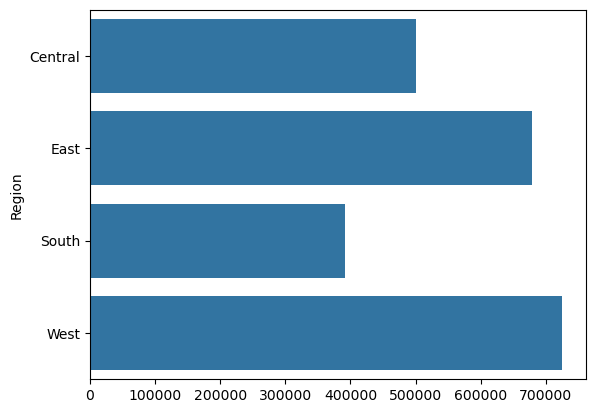

In [12]:
region_sale=df.groupby('Region')['Sales'].sum()
sns.barplot(y=region_sale.index,x=region_sale.values)

<Axes: xlabel='State'>

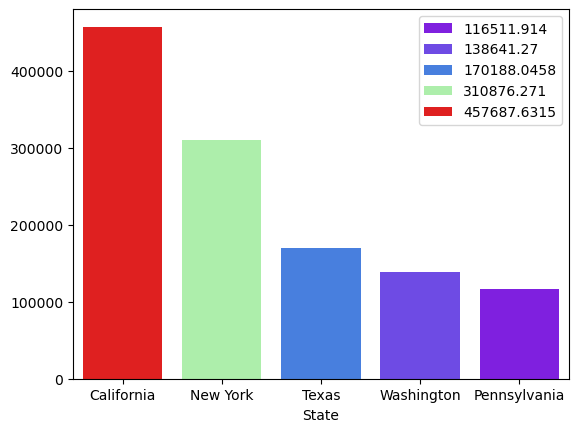

In [13]:
state_sale=df.groupby('State')['Sales'].sum().sort_values(ascending=False).head(5)
sns.barplot(x=state_sale.index,y=state_sale.values,
           hue=state_sale.values,
           palette='rainbow')

<Axes: xlabel='State'>

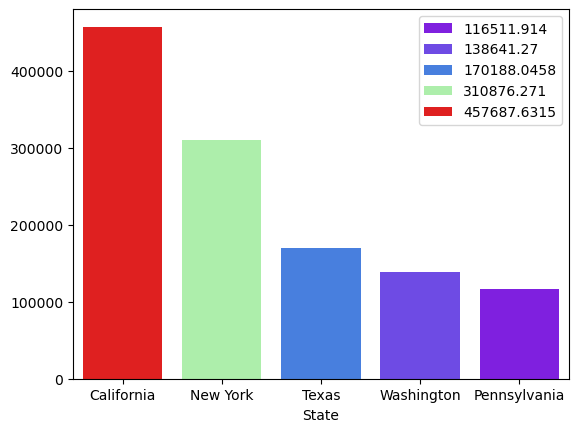

In [14]:
sns.barplot(x=state_sale.index,y=state_sale.values,
           hue=state_sale.values,
           palette='rainbow')

<Axes: xlabel='Segment'>

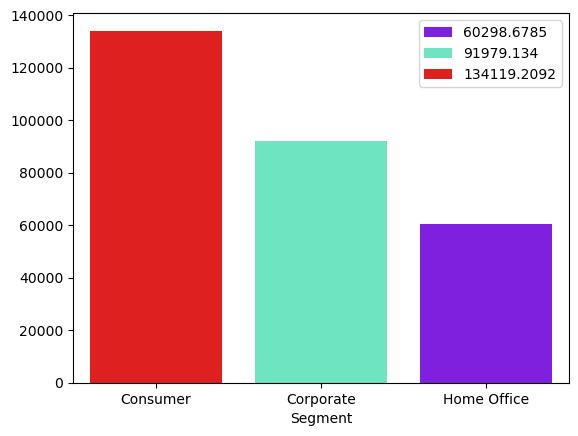

In [15]:
pft_sgmnt=df.groupby('Segment')['Profit'].sum().sort_values(ascending=False)
sns.barplot(x=pft_sgmnt.index,y=pft_sgmnt.values,
           hue=pft_sgmnt.values,
           palette='rainbow')

Exercise 1: Multi-level groupby

In [16]:
df.groupby(['Region','Category'])['Profit'].sum()

Region   Category       
Central  Furniture          -2871.0494
         Office Supplies     8879.9799
         Technology         33697.4320
East     Furniture           3046.1658
         Office Supplies    41014.5791
         Technology         47462.0351
South    Furniture           6771.2061
         Office Supplies    19986.3928
         Technology         19991.8314
West     Furniture          11504.9503
         Office Supplies    52609.8490
         Technology         44303.6496
Name: Profit, dtype: float64

<Axes: xlabel='Region', ylabel='Profit'>

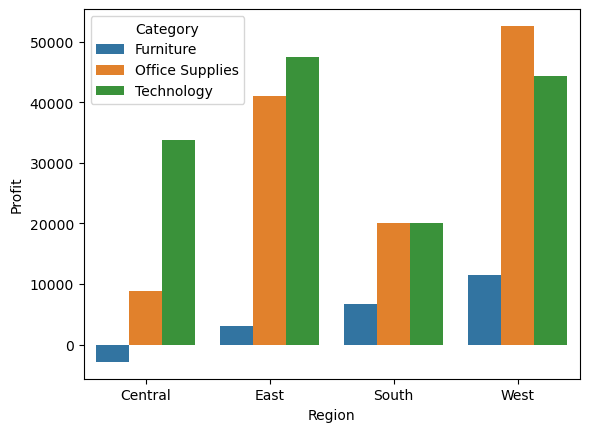

In [17]:
result = df.groupby(['Region','Category'])['Profit'].sum().reset_index()
sns.barplot(data=result, x='Region', y='Profit', hue='Category')

your profit avg is0.08104368329610324 and loss is 0.48088722608230894 


<Axes: >

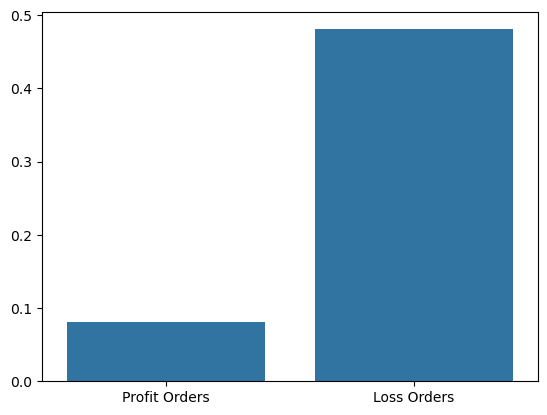

In [18]:
m_l=df[df['Profit']<0]['Discount'].mean()
m_p=df[df['Profit']>0]['Discount'].mean()
print(f'your profit avg is{m_p} and loss is {m_l} ')
import seaborn as sns
sns.barplot(x=['Profit Orders','Loss Orders'], y=[m_p, m_l])

Profit margin

<Axes: xlabel='Category'>

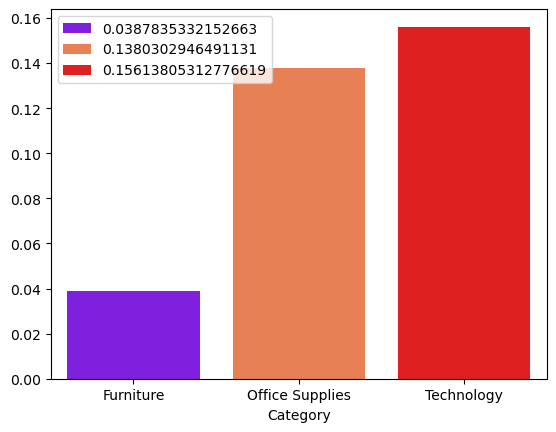

In [19]:
df['Margin']=df['Profit']/df['Sales']
margin_p=df.groupby('Category')['Margin'].mean()
sns.barplot(x=margin_p.index,y=margin_p.values,
          hue=margin_p.values,
           palette='rainbow')

In [23]:
df[['Sales','Profit','Discount','Quantity','Margin']].corr()

,Sales,Profit,Discount,Quantity,Margin
Sales,1.000000,0.479064,-0.028190,0.200795,0.003444
Profit,0.479064,1.000000,-0.219487,0.066253,0.223732
Discount,-0.028190,-0.219487,1.000000,0.008623,-0.864452
Quantity,0.200795,0.066253,0.008623,1.000000,-0.005280
Margin,0.003444,0.223732,-0.864452,-0.005280,1.000000


<Axes: >

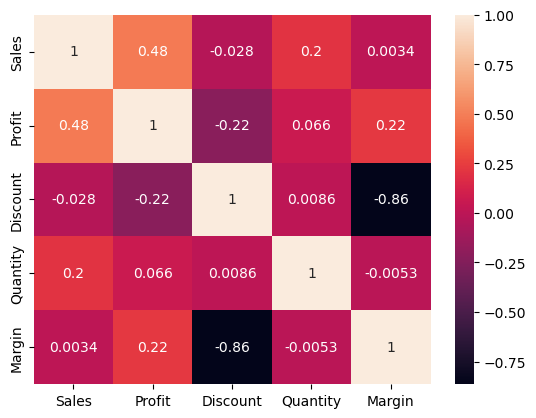

In [24]:
sns.heatmap(df[['Sales','Profit','Discount','Quantity','Margin']].corr(), 
            annot=True)

<Axes: xlabel='Order Year'>

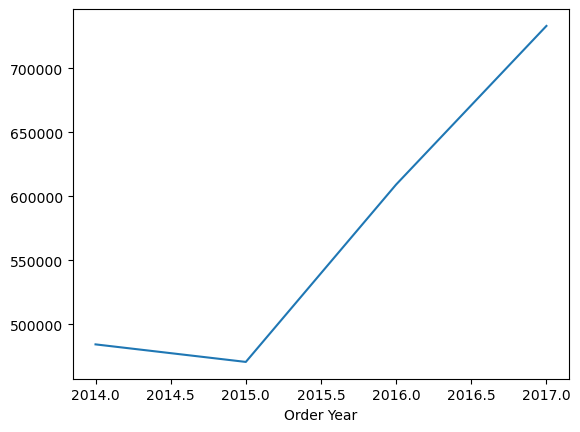

In [30]:
sale_accrding_year=df.groupby('Order Year')['Sales'].sum()
sns.lineplot(x=sale_accrding_year.index, y=sale_accrding_year.values)

<Axes: xlabel='Ship Mode'>

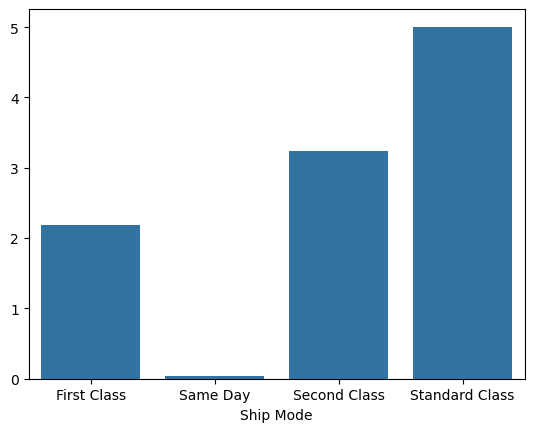

In [39]:
df['Ship Mode'].unique()
shipping_avg =df.groupby('Ship Mode')['Shipping Days'].mean()
shipping_avg.sort_values()
sns.barplot(x=shipping_avg.index,y=shipping_avg.values)

In [22]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Order Year',
       'Order Month', 'Shipping Days', 'Margin'],
      dtype='object')

In [21]:
df.head(15)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Order Year,Order Month,Shipping Days,Margin
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11,3,0.1600
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11,3,0.3000
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,6,4,0.4700
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10,7,-0.4000
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,10,7,0.1125
5,6,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600,7,0.00,14.1694,2014,6,5,0.2900
6,7,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,Art,Newell 322,7.2800,4,0.00,1.9656,2014,6,5,0.2700
7,8,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,Phones,Mitel 5320 IP Phone VoIP phone,907.1520,6,0.20,90.7152,2014,6,5,0.1000
8,9,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,Binders,DXL Angle-View Binders with Locking Rings by S...,18.5040,3,0.20,5.7825,2014,6,5,0.3125
9,10,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,Appliances,Belkin F5C206VTEL 6 Outlet Surge,114.9000,5,0.00,34.4700,2014,6,5,0.3000
